In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("/content/OnlineRetail.csv", encoding='latin1')


In [3]:

print("First 5 Records")
print(df.head())


First 5 Records
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())




Dataset Shape:
(541909, 8)

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:

df.dropna(subset=['CustomerID', 'Description'], inplace=True)

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

print("\nShape After Cleaning:")
print(df.shape)




Shape After Cleaning:
(397884, 8)


In [6]:

top_products = df['Description'].value_counts().head(10)

print("\nTop 10 Most Purchased Products:")
print(top_products)




Top 10 Most Purchased Products:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64


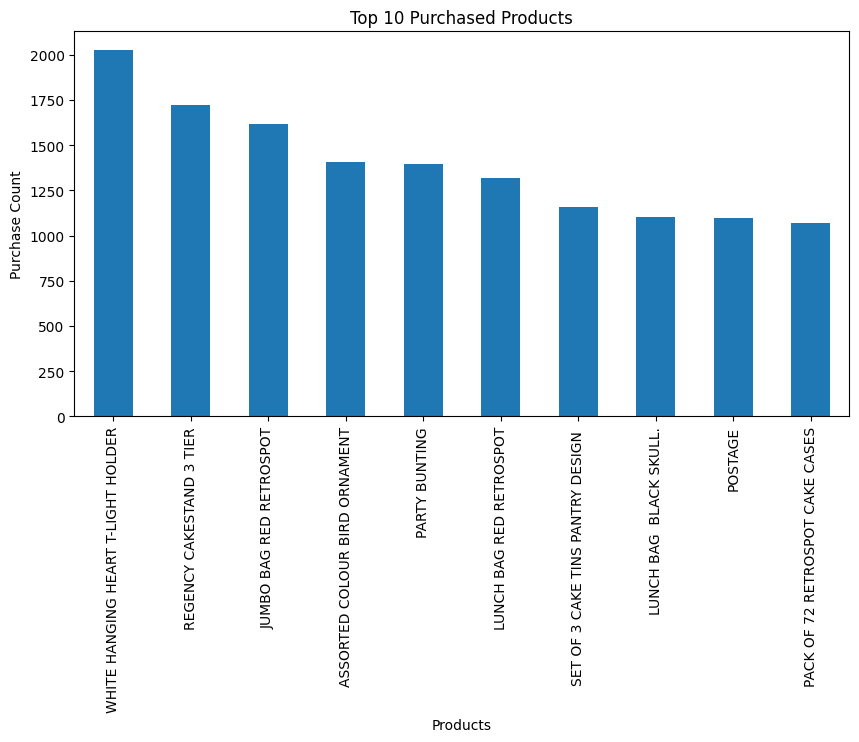

In [7]:

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Purchased Products")
plt.xlabel("Products")
plt.ylabel("Purchase Count")
plt.xticks(rotation=90)
plt.show()



In [8]:


recommendations = df['Description'].value_counts().head(5)

print("\nRecommended Products:")
for i, product in enumerate(recommendations.index, start=1):
    print(i, "-", product)


Recommended Products:
1 - WHITE HANGING HEART T-LIGHT HOLDER
2 - REGENCY CAKESTAND 3 TIER
3 - JUMBO BAG RED RETROSPOT
4 - ASSORTED COLOUR BIRD ORNAMENT
5 - PARTY BUNTING


In [9]:

result = pd.DataFrame({
    'Rank': range(1, 6),
    'Recommended Product': recommendations.index
})

print("\nRecommendation Results:")
print(result)



Recommendation Results:
   Rank                 Recommended Product
0     1  WHITE HANGING HEART T-LIGHT HOLDER
1     2            REGENCY CAKESTAND 3 TIER
2     3             JUMBO BAG RED RETROSPOT
3     4       ASSORTED COLOUR BIRD ORNAMENT
4     5                       PARTY BUNTING
